In [16]:
import sys
import os
sys.path.append(os.path.abspath('..'))


import pandas as pd
import numpy as np

from data_preparation.data_processor import DataProcessor
from models import XGBoostParams

import xgboost as xgb
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL


In [17]:
XGBoostParams =  {
    "Municipal": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 4,
        "min_child_weight": 3,
        "n_estimators": 90,
        "reg_alpha": 0,
        "reg_lambda": 1
    },
    "Industrial": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 5,
        "n_estimators": 70,
        "reg_alpha": 0,
        "reg_lambda": 0.5
    },
    "Organic": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 5,
        "n_estimators": 110,
        "reg_alpha": 0.5,
        "reg_lambda": 1
    },
    "Construction": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.09000000000000001,
        "max_depth": 3,
        "min_child_weight": 5,
        "n_estimators": 70,
        "reg_alpha": 0,
        "reg_lambda": 1
    },
    "Commercial": {
        "colsample_bytree": 1.0,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 3,
        "n_estimators": 70,
        "reg_alpha": 0.5,
        "reg_lambda": 1
    }
}

In [18]:
waste_data = pd.read_csv("../synthetic_waste_data.csv")

fetcher = DataProcessor(waste_data)

unique_waste = fetcher.waste_data['waste_type'].unique()
waste_dfs = {}

lags = [6,7,13,14,20,21]

for waste in unique_waste:
    prep_data_company = fetcher.agg_quantity(waste_type=waste, by_waste_type= True)
    # Perform seasonal decomposition on the entire data
    #stl = STL(prep_data_company['quantity_tons'], period=12)
    #res = stl.fit()
    #
    ## Extract the seasonal component for the entire data
    #seasonal = res.seasonal
    #
    ## Shift the seasonal component by one period
    #seasonal_shifted = seasonal.shift(-1)
    #
    ## Create a new feature based on the shifted seasonal component
    #prep_data_company['seasonal_shifted'] = seasonal_shifted
    waste_dfs[waste] = fetcher.create_xgboost_features(prep_data_company,waste_type= waste ,lags=lags, lagged_features= False,lagged_ratios= True ,fourier_terms= True, interaction_terms= False)


for c in range(len(unique_waste)):
    waste = list(waste_dfs.keys())[c]
    print(f"Data shape for {waste}:")
    print(waste_dfs[waste].shape)

Data shape for Municipal:
(1096, 25)
Data shape for Industrial:
(1096, 23)
Data shape for Organic:
(1096, 21)
Data shape for Construction:
(1096, 23)
Data shape for Commercial:
(1096, 23)


In [19]:
waste_dfs["Municipal"]

,is_Fall,is_Spring,is_Summer,is_Winter,quantity_tons,is_weekend,is_holiday,dayofweek,quarter,month,...,lag_ratio_7_13,lag_ratio_13_14,lag_ratio_14_20,lag_ratio_20_21,annual_fourier_sin,annual_fourier_cos,weekly_fourier_sin,weekly_fourier_cos,semi_weekly_fourier_sin,semi_weekly_fourier_cos
date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,0.0,0.0,0.0,1.0,16.381126,1.0,1.0,5,1,1,...,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000
2022-01-02,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,6,1,1,...,NaN,NaN,NaN,NaN,0.017198,0.999852,7.818315e-01,0.623490,9.749279e-01,-0.222521
2022-01-03,0.0,0.0,0.0,1.0,230.263626,0.0,0.0,0,1,1,...,NaN,NaN,NaN,NaN,0.034391,0.999408,9.749279e-01,-0.222521,-4.338837e-01,-0.900969
2022-01-04,0.0,0.0,0.0,1.0,124.063835,0.0,0.0,1,1,1,...,NaN,NaN,NaN,NaN,0.051573,0.998669,4.338837e-01,-0.900969,-7.818315e-01,0.623490
2022-01-05,0.0,0.0,0.0,1.0,74.480949,0.0,0.0,2,1,1,...,NaN,NaN,NaN,NaN,0.068740,0.997635,-4.338837e-01,-0.900969,7.818315e-01,0.623490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,0.0,0.0,0.0,1.0,232.099213,0.0,1.0,4,4,12,...,1.867744,0.308269,NaN,0.000000,-0.085716,0.996320,-7.818315e-01,0.623490,-9.749279e-01,-0.222521
2024-12-28,0.0,0.0,0.0,1.0,91.199692,1.0,1.0,5,4,12,...,2.142801,0.330443,1.117542,NaN,-0.068569,0.997646,4.705615e-14,1.000000,9.411230e-14,1.000000
2024-12-29,0.0,0.0,0.0,1.0,6.269297,1.0,0.0,6,4,12,...,0.094301,10.974544,0.051128,7.222709,-0.051401,0.998678,7.818315e-01,0.623490,9.749279e-01,-0.222521


<Figure size 1000x800 with 0 Axes>

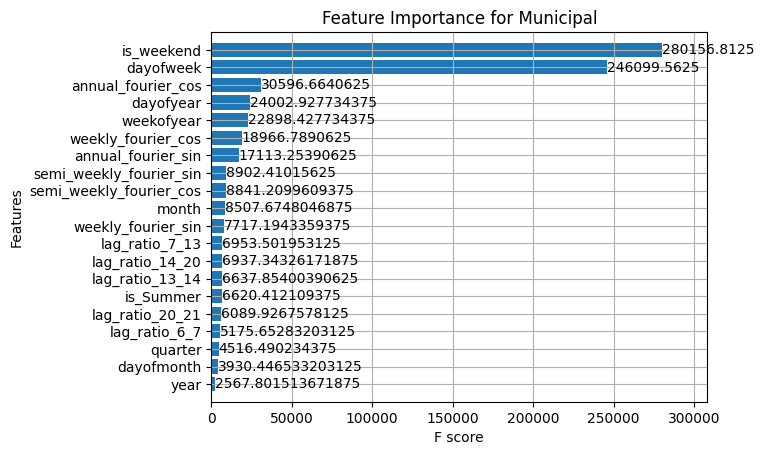

<Figure size 1000x800 with 0 Axes>

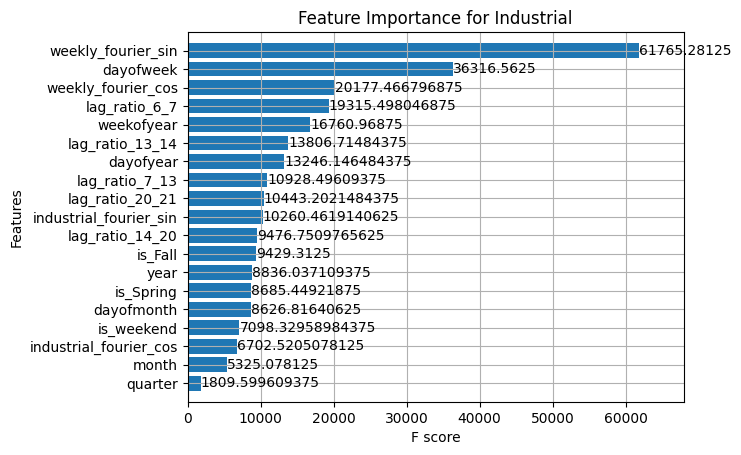

<Figure size 1000x800 with 0 Axes>

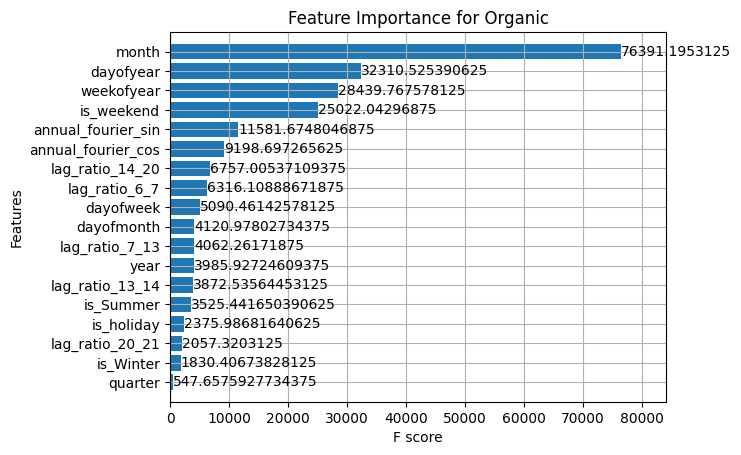

<Figure size 1000x800 with 0 Axes>

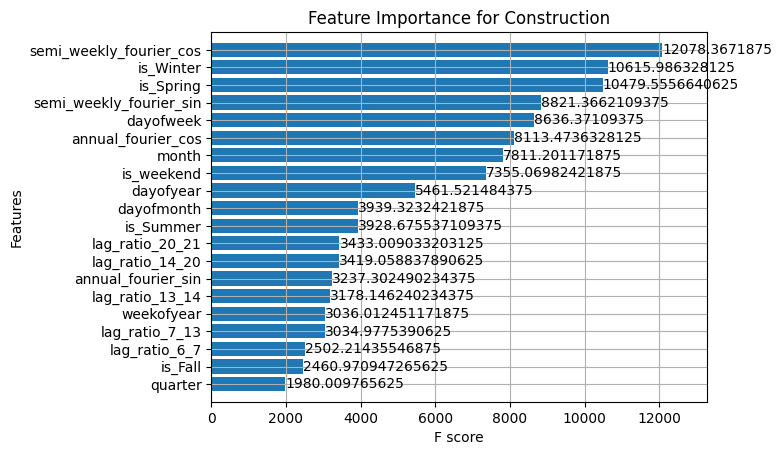

<Figure size 1000x800 with 0 Axes>

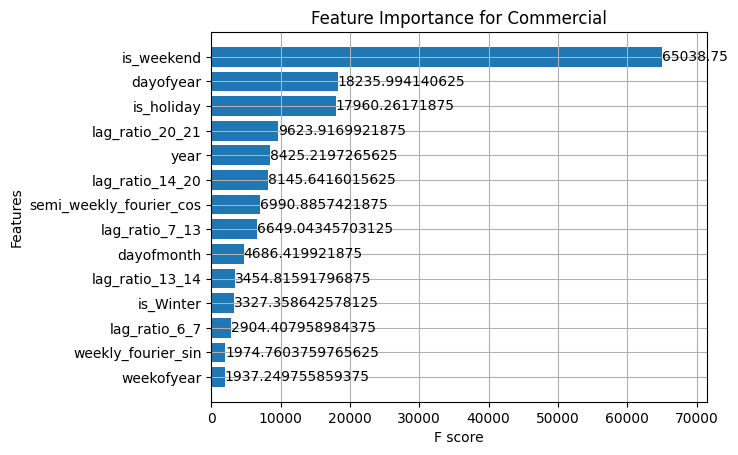

In [20]:
split_index = int(waste_dfs["Municipal"].shape[0] * 0.8)


waste_quantity_preds = {}

for waste, df in waste_dfs.items():

    X = df.drop(columns=['quantity_tons'])
    y = df['quantity_tons']

    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]
    
    # Get the best parameters for this company
    best_params = XGBoostParams[waste]
    
    
    # Create and train the model with best parameters
    best_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        **best_params  # Unpack the parameters
    )
    
    best_model.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)
    waste_quantity_preds[waste] = y_pred

    # Plot feature importance
    plt.figure(figsize=(10, 8))
    xgb.plot_importance(best_model, max_num_features=20, height=0.8, importance_type="gain")
    plt.title(f"Feature Importance for {waste}")
    plt.show()

RMSE:96.62821197509766
RMSE for Municipal: 50.13999938964844
RMSE for Industrial: 41.4900016784668
RMSE for Organic: 35.83000183105469
RMSE for Construction: 30.290000915527344
RMSE for Commercial: 34.81999969482422


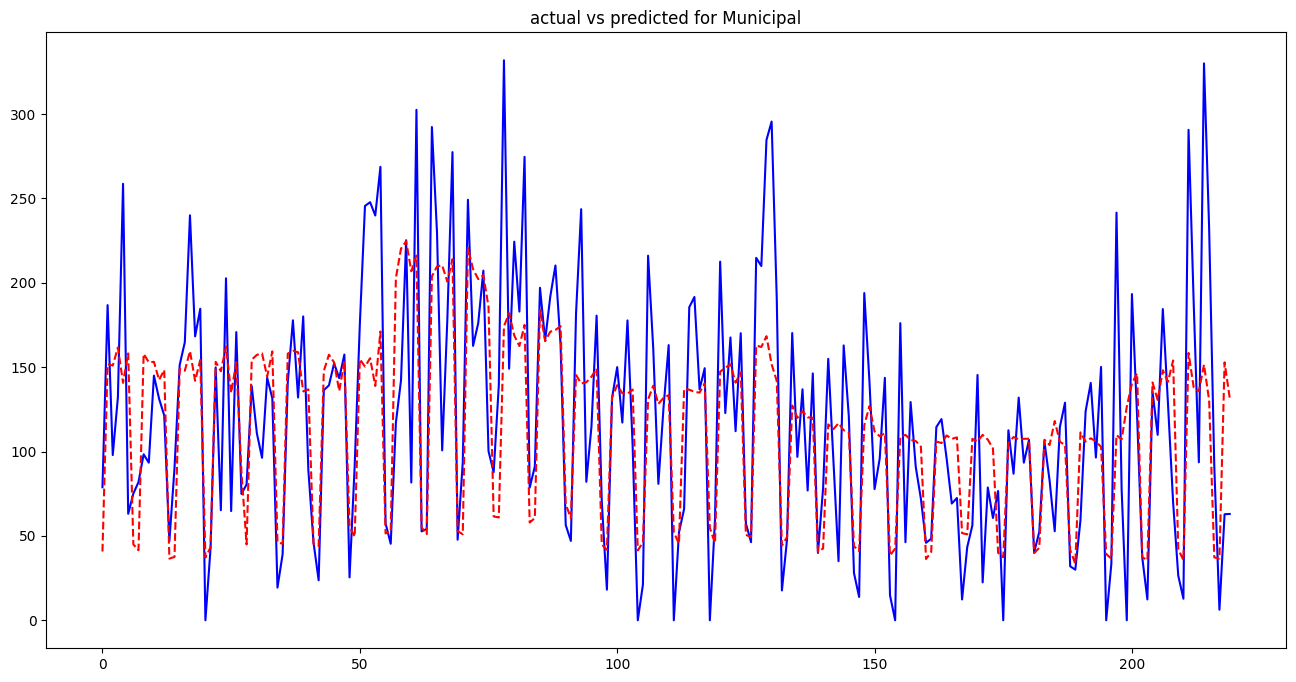

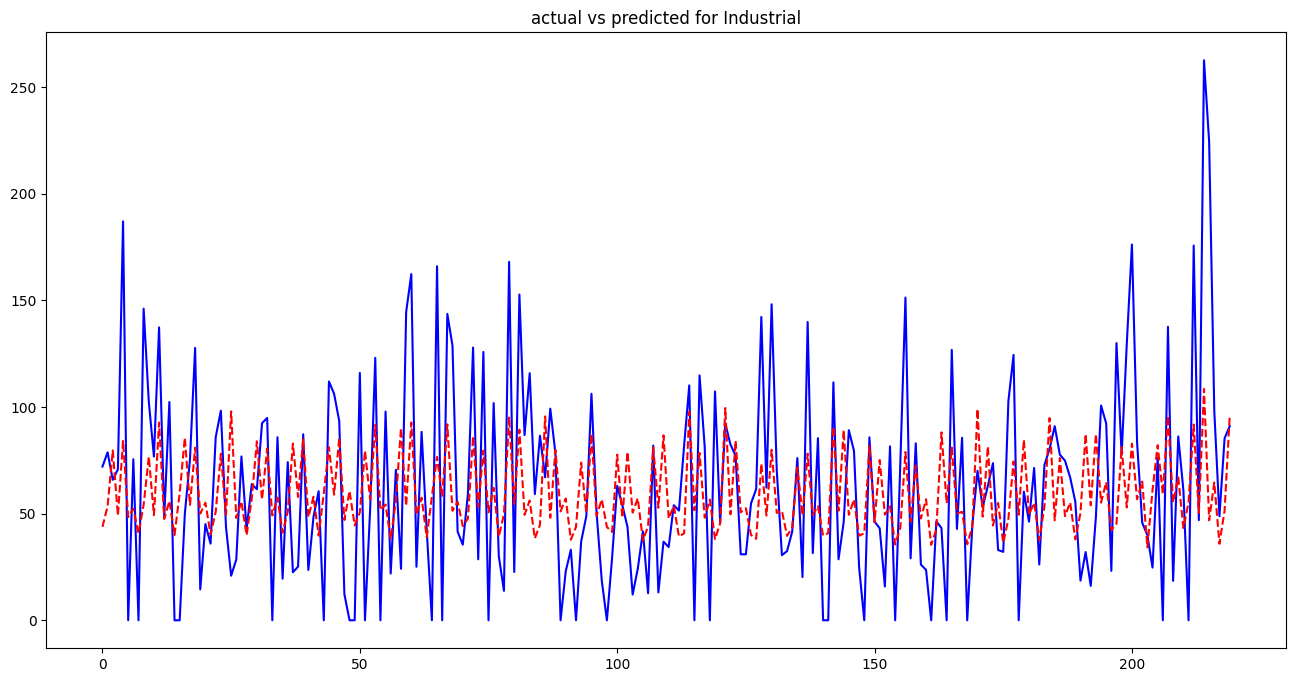

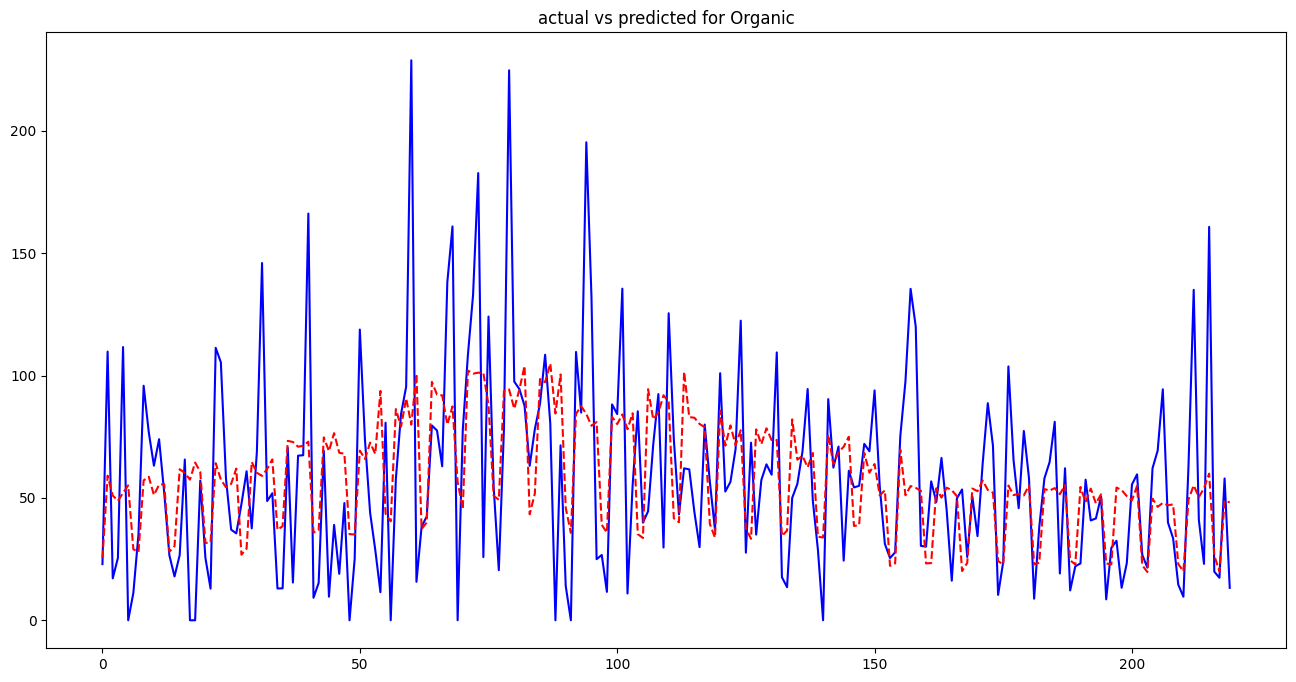

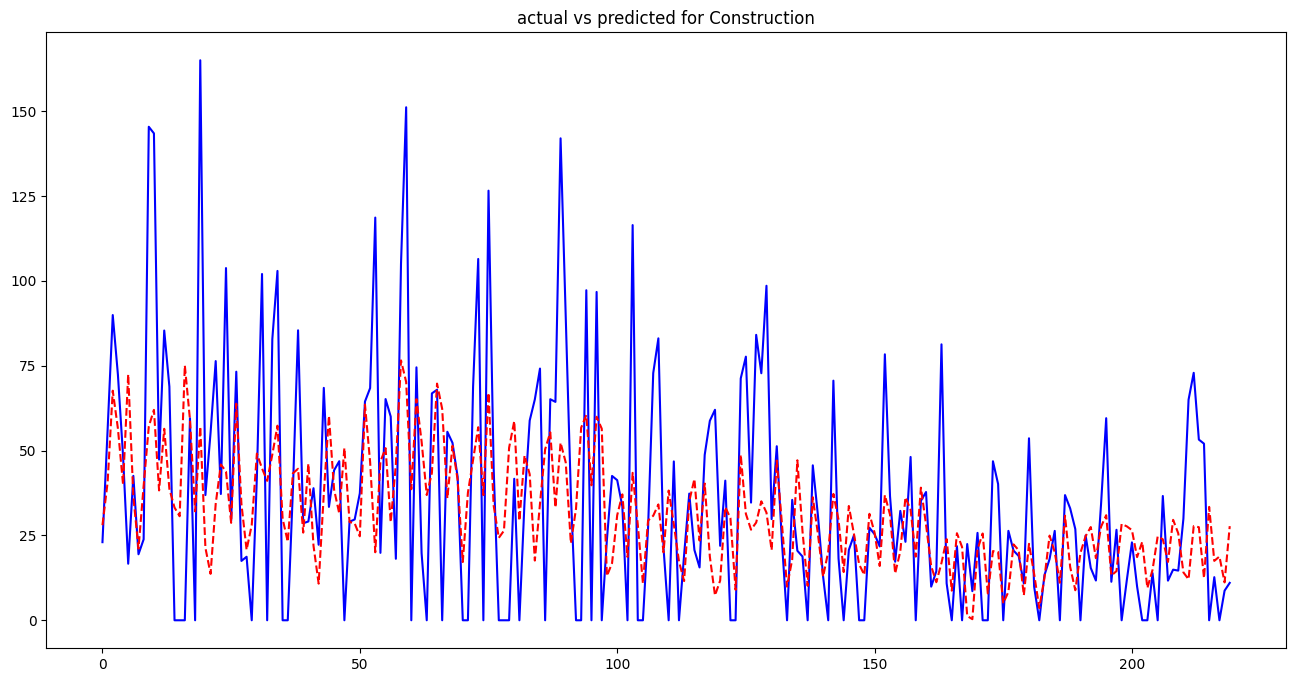

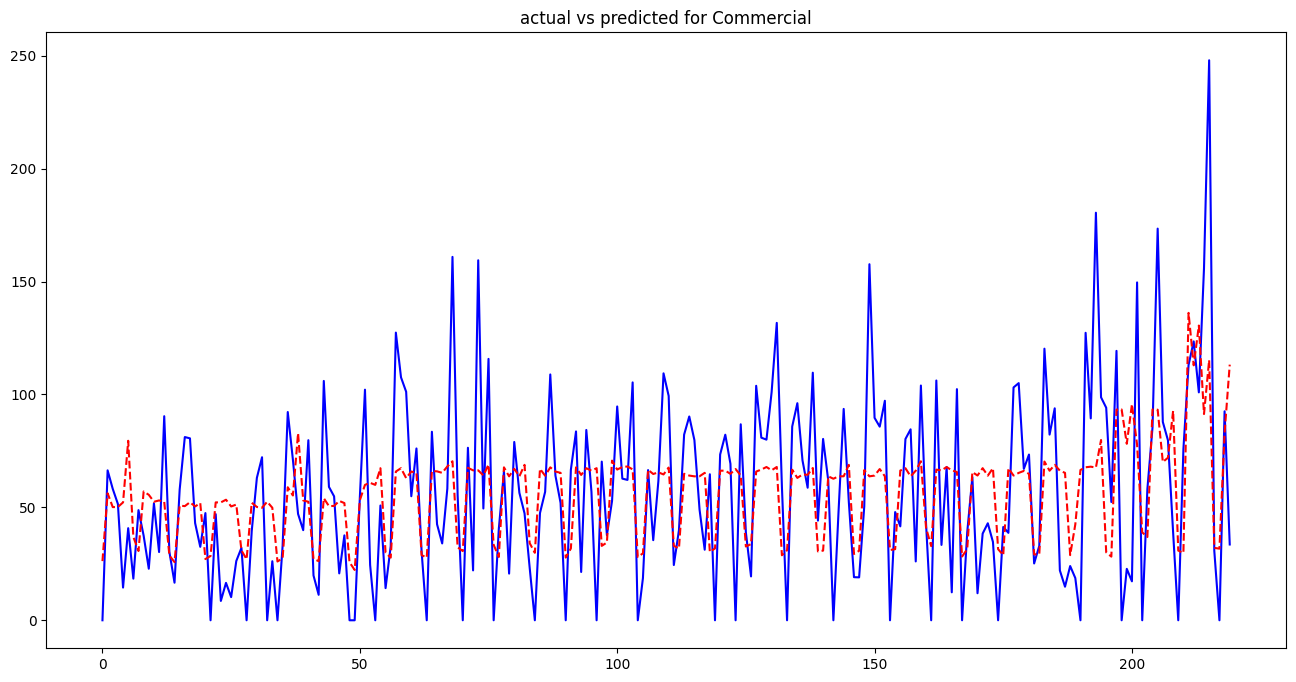

In [21]:
from sklearn.metrics import root_mean_squared_error

total_actual = np.sum(
    [waste_dfs[waste]['quantity_tons'].values[split_index:] for waste in waste_dfs],
    axis=0
)


total_predicted = np.sum(list(waste_quantity_preds.values()), axis=0)

print(f"RMSE:{root_mean_squared_error(total_actual, total_predicted)}")

for waste in unique_waste:
    actual = np.sum(
    [waste_dfs[waste]['quantity_tons'].values[split_index:]],
    axis=0)

    predicted = waste_quantity_preds[waste]

    plt.figure(figsize = (16,8))
    plt.plot(actual, color = "blue")
    plt.plot(predicted, color = "red", linestyle = "dashed")
    plt.title(f"actual vs predicted for {waste}")

    print(f"RMSE for {waste}: {round(root_mean_squared_error(actual, predicted),2)}")


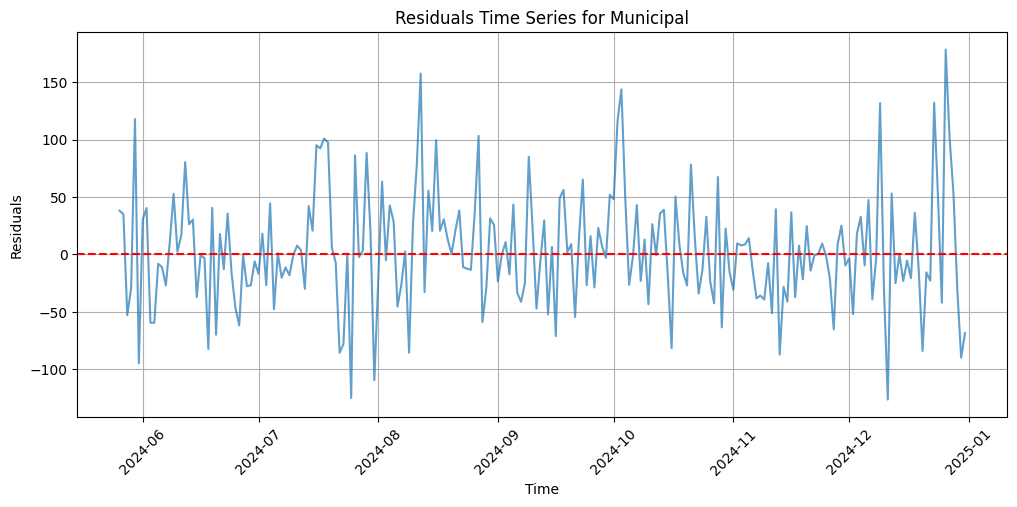

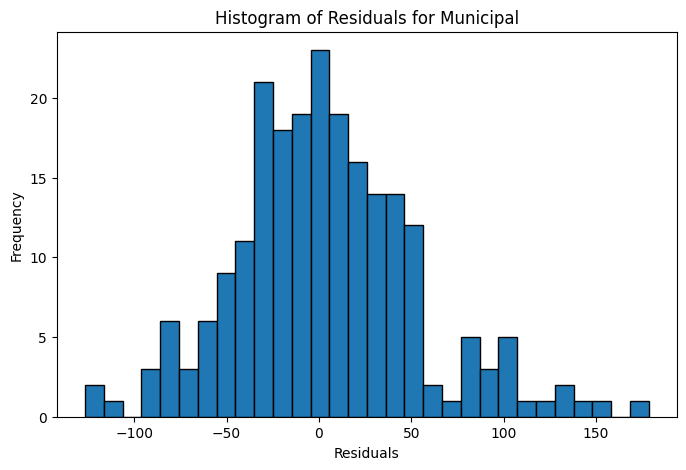

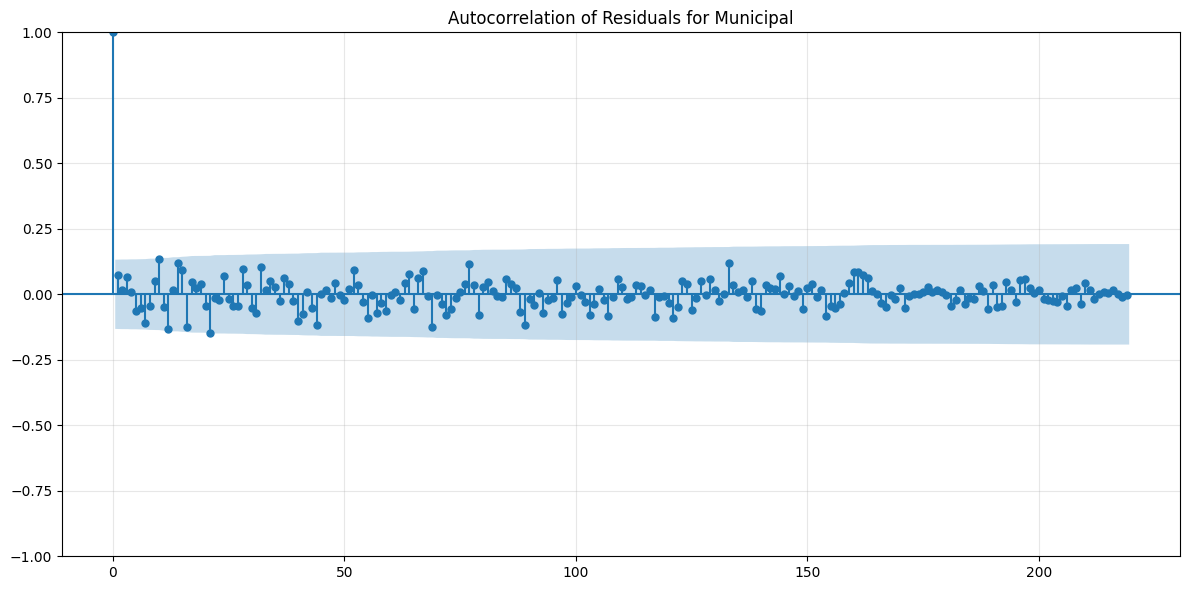

      lb_stat  lb_pvalue
30  39.038915   0.124859
60  64.511111   0.321879
90  98.479908   0.253804



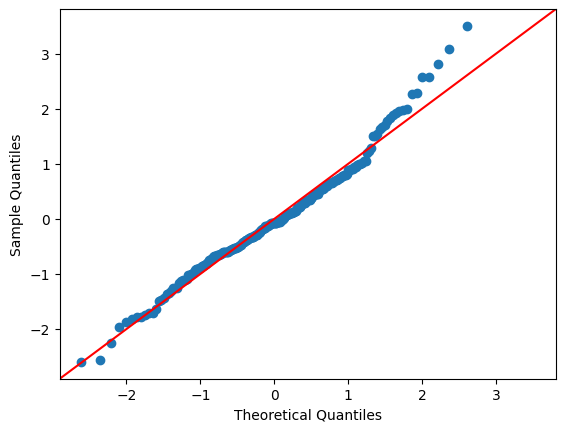

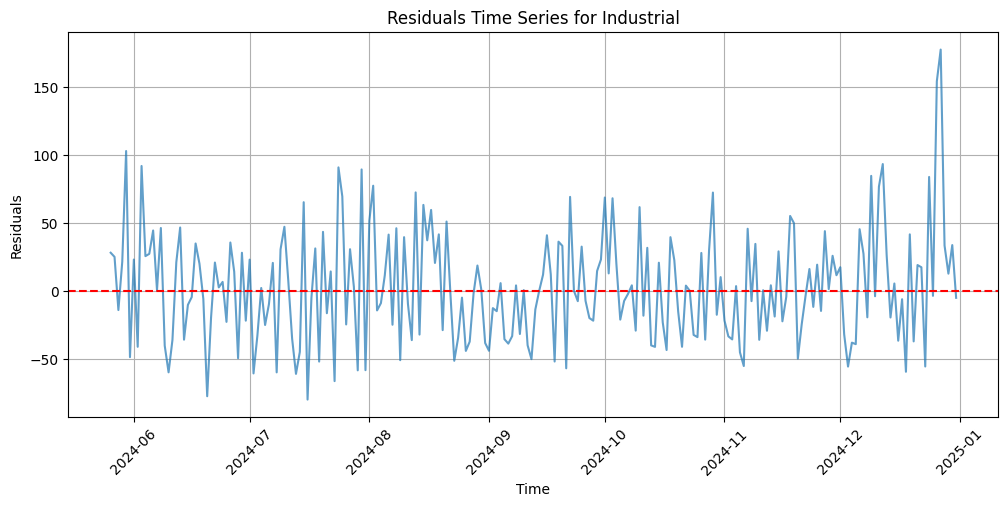

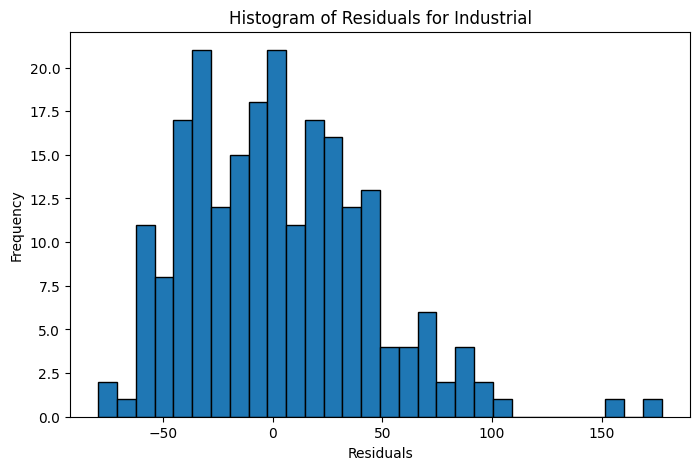

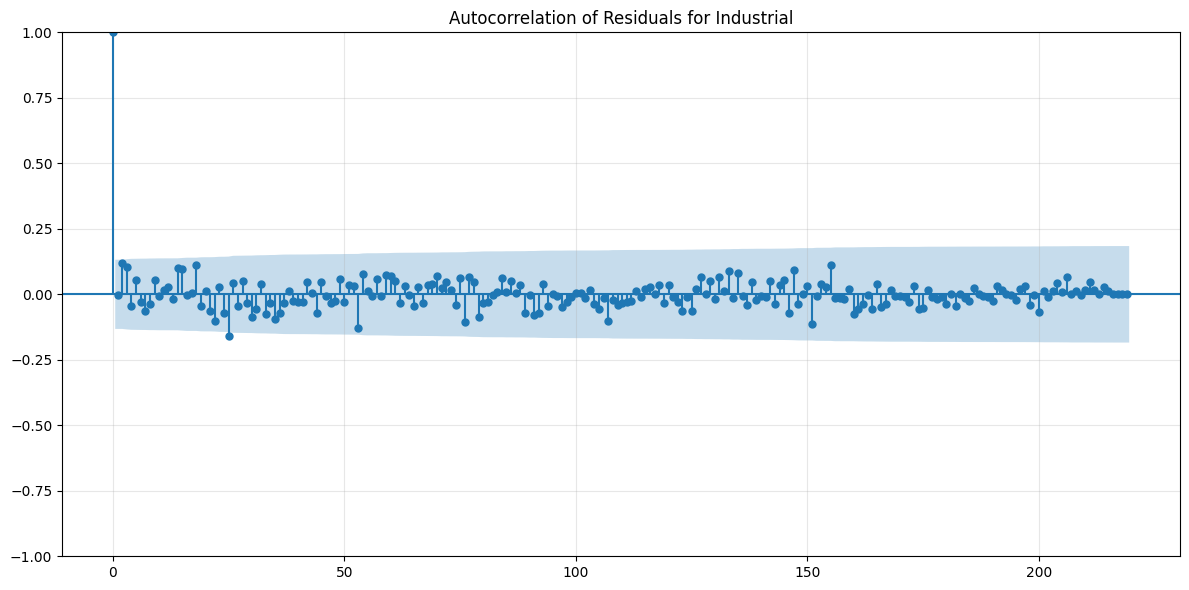

      lb_stat  lb_pvalue
30  32.228469   0.356978
60  55.617244   0.636449
90  77.865841   0.815489



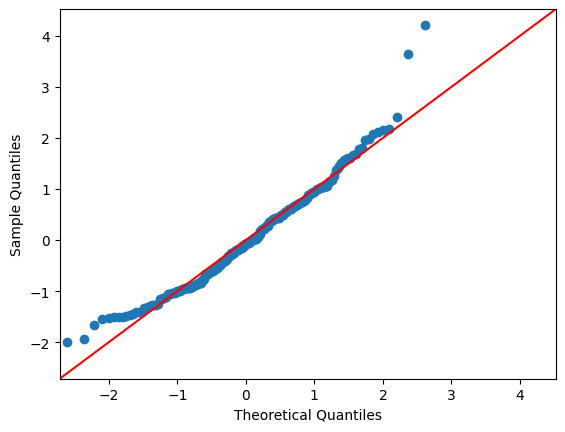

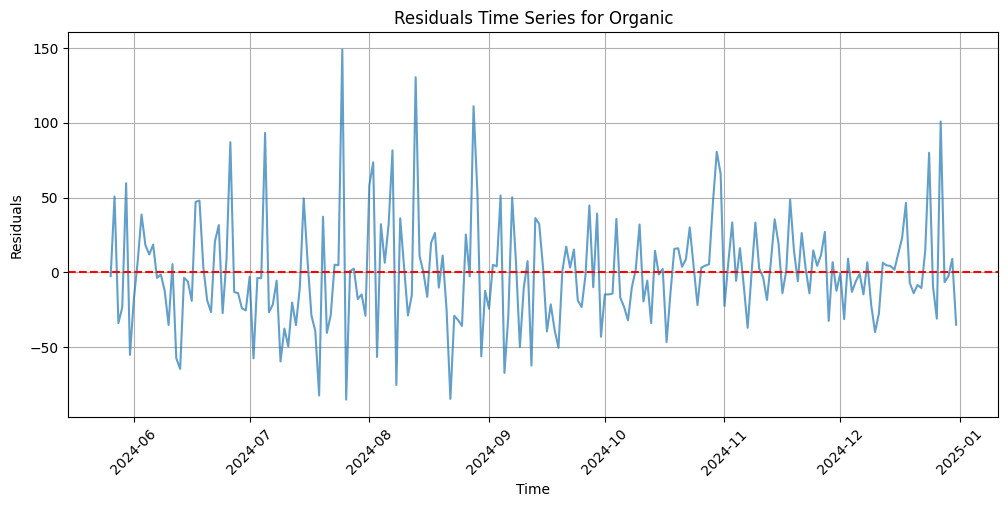

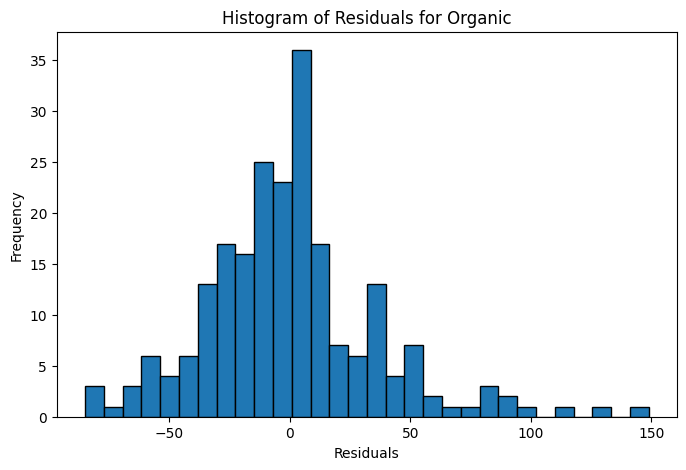

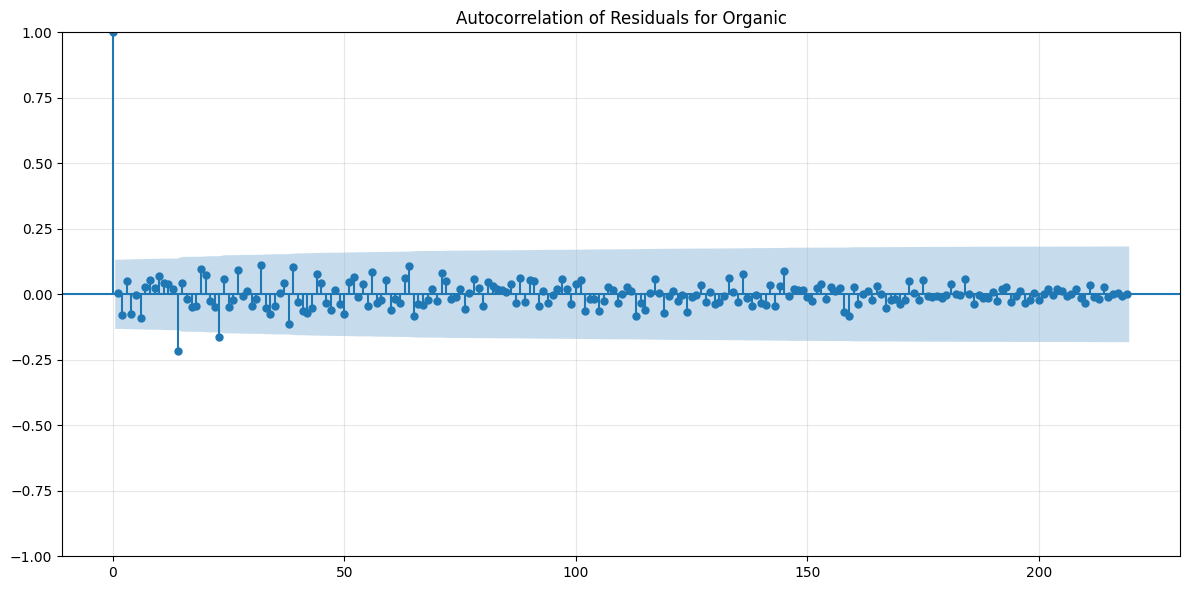

      lb_stat  lb_pvalue
30  36.099967   0.204823
60  65.558195   0.290142
90  86.125797   0.596044



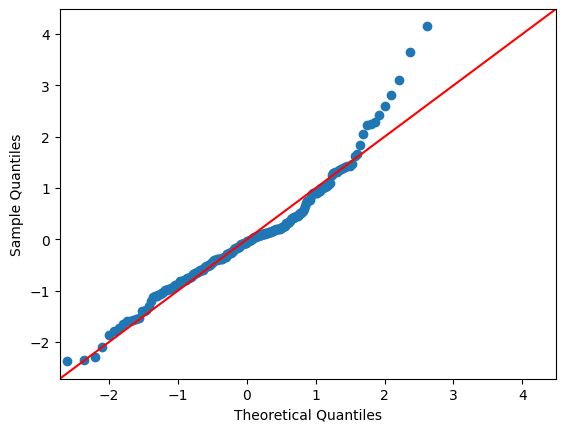

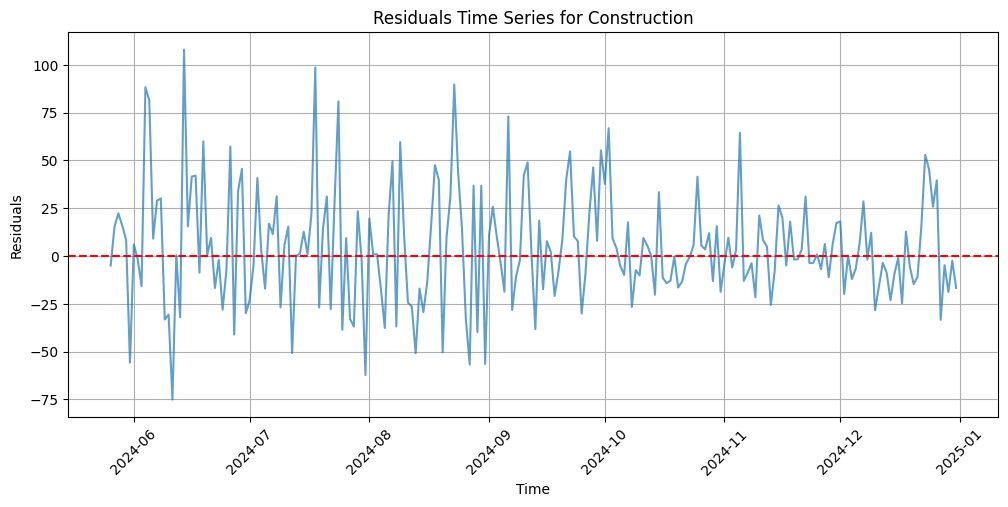

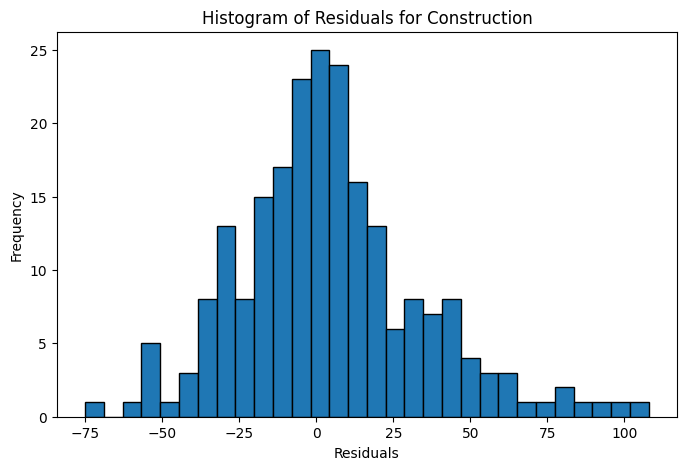

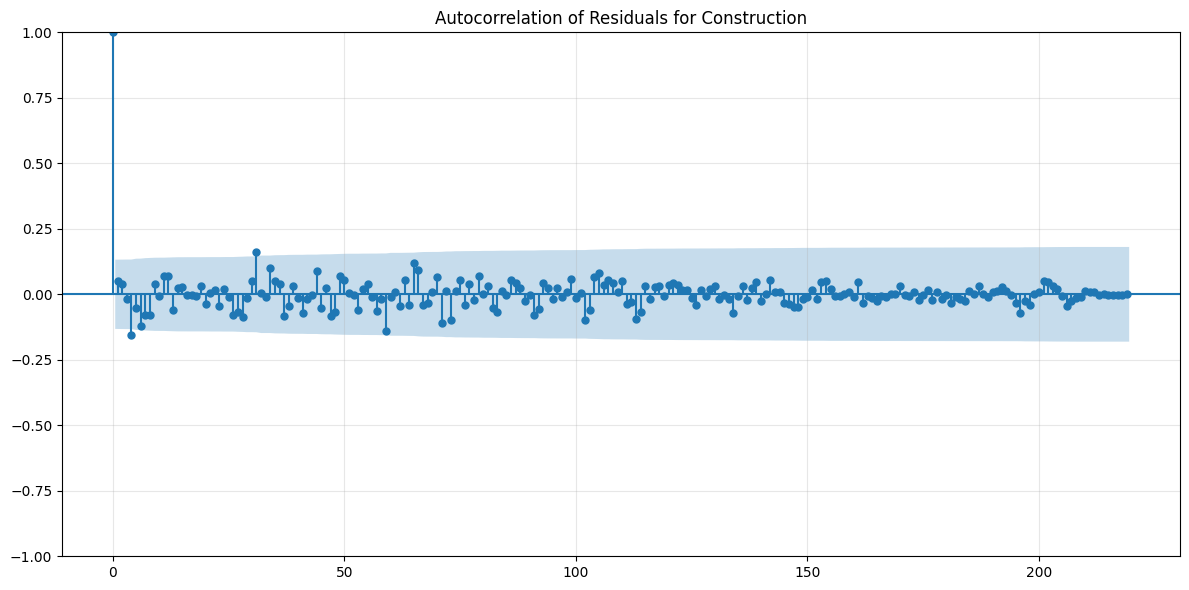

      lb_stat  lb_pvalue
30  23.657861   0.787279
60  55.869476   0.627341
90  83.757410   0.665129



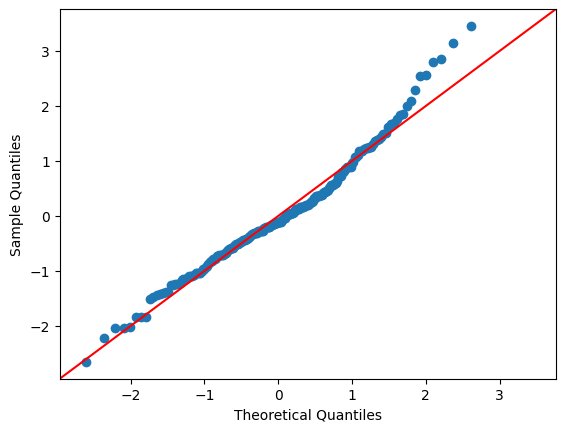

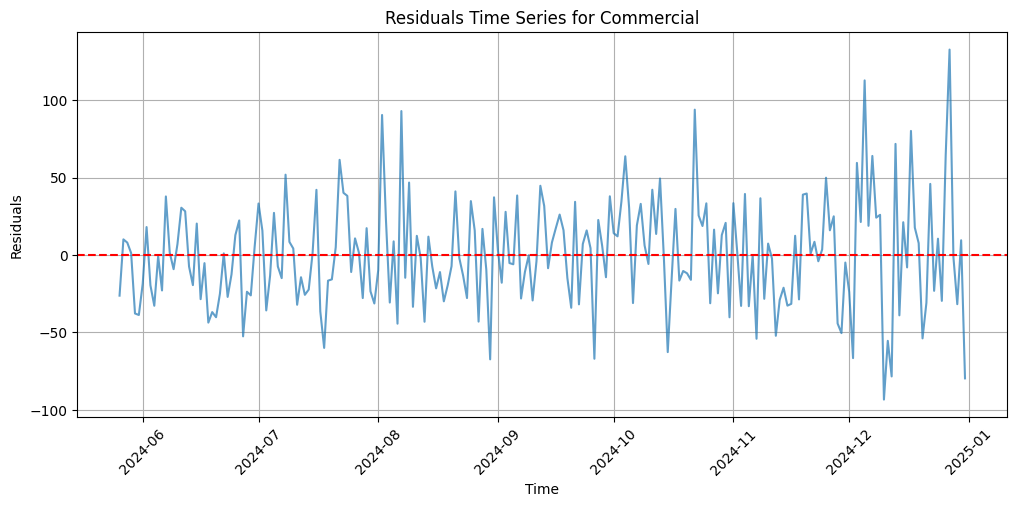

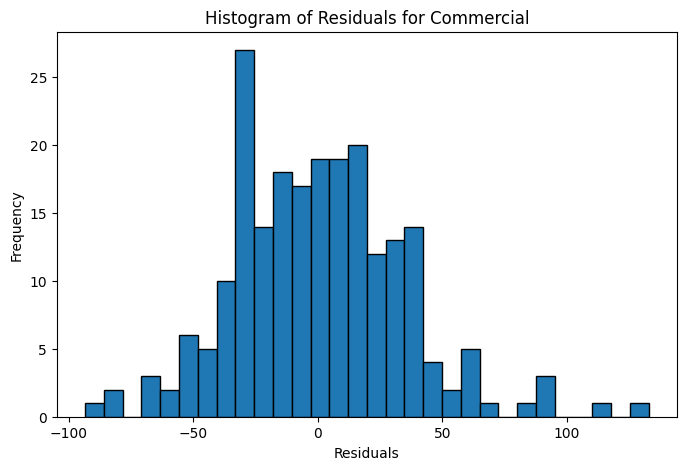

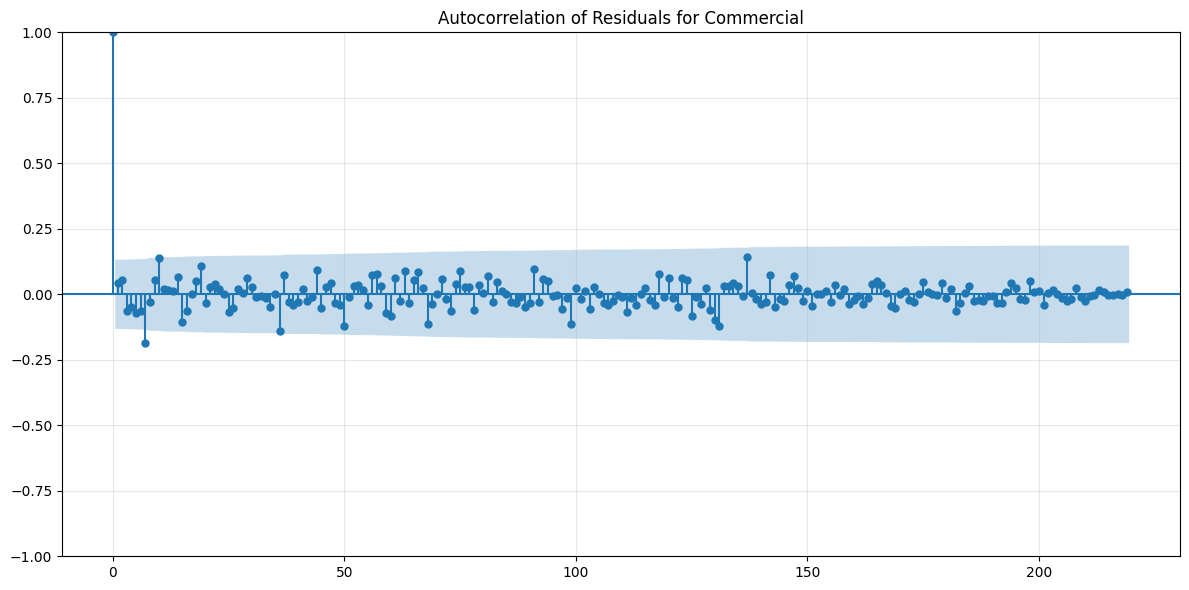

      lb_stat  lb_pvalue
30  30.334352   0.448629
60  56.105449   0.618780
90  81.266049   0.733423



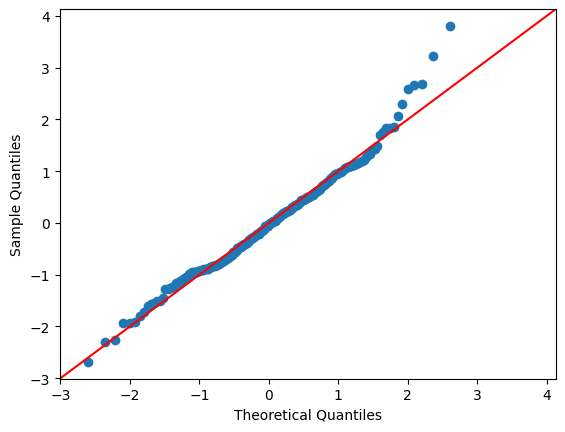

In [22]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

for waste in waste_dfs:

    # Calculate total actual values for the waste type
    total_actual = waste_dfs[waste]['quantity_tons'].values[split_index:]
    # Calculate total predicted values for the waste type
    total_predicted = waste_quantity_preds[waste]
    # Calculate residuals
    residuals = total_actual - total_predicted
    # Get the time index for the residuals
    time_index = waste_dfs[waste].index[split_index:]
    # Plot residuals as points over time
    plt.figure(figsize=(12, 5))
    plt.plot(time_index, residuals, alpha=0.7)
    plt.axhline(y=0, color="red", linestyle="--")  # Zero-line for reference
    plt.xlabel("Time")
    plt.ylabel("Residuals")
    plt.title(f"Residuals Time Series for {waste}")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    # Plot histogram of residuals
    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=30, edgecolor="black")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Residuals for {waste}")
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))
    plot_acf(residuals, ax=ax, lags=len(residuals)-1)  
    plt.title(f'Autocorrelation of Residuals for {waste}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    result = acorr_ljungbox(residuals, lags=[30,60,90], return_df=True)  
    print(f"{result}\n")

    sm.qqplot(residuals, line='45', fit=True)
    plt.show()

    # Print mean and standard deviation of residuals
    #print(f"{waste} - Mean Residual: {residuals.mean():.2f}")
    #print(f"{waste} - Standard Deviation: {residuals.std():.2f}")
